In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [5]:
import seaborn as sns

In [6]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [7]:
dfSucio = pd.read_csv("dataset_sucio_practica.csv")

In [8]:
#Mostrar las primeras filas
dfSucio.head(5)

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
0,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
1,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
2,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
3,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
4,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí


In [9]:
dfSucio.shape

(125, 8)

In [10]:
dfSucio.tail()

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
120,1,Julia Zhang,150.0,aortiz@perry.com,NaN,25000.0,2026-03-09,Sí
121,2,NaN,35.0,asimmons@garza.com,España,NaN,2026-05-04,No
122,3,George Burke,40.0,mcclainerin@gmail.com,Argentina,NaN,2026-01-27,NaN
123,4,Joyce Williams,30.0,correo_invalido,Argentina,25000.0,2025-02-23,No
124,5,Elaine Sanchez,-5.0,correo_invalido,México,25000.0,2025-03-28,Sí


In [65]:
dfSucio.describe()

,id,edad,salario,fecha_registro,activo
count,120.000000,120.000000,120.000000,120,120.000000
mean,60.500000,30.325000,16741.666667,2025-06-07 04:12:00,0.675000
min,1.000000,22.000000,12000.000000,2024-05-31 00:00:00,0.000000
25%,30.750000,30.000000,15000.000000,2024-11-15 00:00:00,0.000000
50%,60.500000,30.000000,15000.000000,2025-06-19 12:00:00,1.000000
75%,90.250000,31.250000,18000.000000,2025-12-18 18:00:00,1.000000
max,120.000000,40.000000,25000.000000,2026-05-04 00:00:00,1.000000
std,34.785054,4.745918,4401.099621,NaN,0.470339


In [12]:
dfSucio[dfSucio["id"].isin([29, 55, 58])]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
28,29,Teresa Ramos,22.0,rileyraymond@hotmail.com,México,-1000.0,2025-08-29,NaN
54,55,John Lewis,NaN,rodriguezbrett@yahoo.com,México,-1000.0,2024-07-03,NaN
57,58,Michael Barajas,40.0,antoniocox@hotmail.com,España,15000.0,2026-05-02,NaN


In [13]:
#Generamos una copia por cualquier cosa
dfCopy = dfSucio.copy()

In [14]:
dfSucio.info()

<class 'pandas.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              125 non-null    int64  
 1   nombre          116 non-null    str    
 2   edad            110 non-null    float64
 3   correo          125 non-null    str    
 4   pais            82 non-null     str    
 5   salario         107 non-null    float64
 6   fecha_registro  125 non-null    str    
 7   activo          90 non-null     str    
dtypes: float64(2), int64(1), str(5)
memory usage: 7.9 KB


<function matplotlib.pyplot.show(close=None, block=None)>

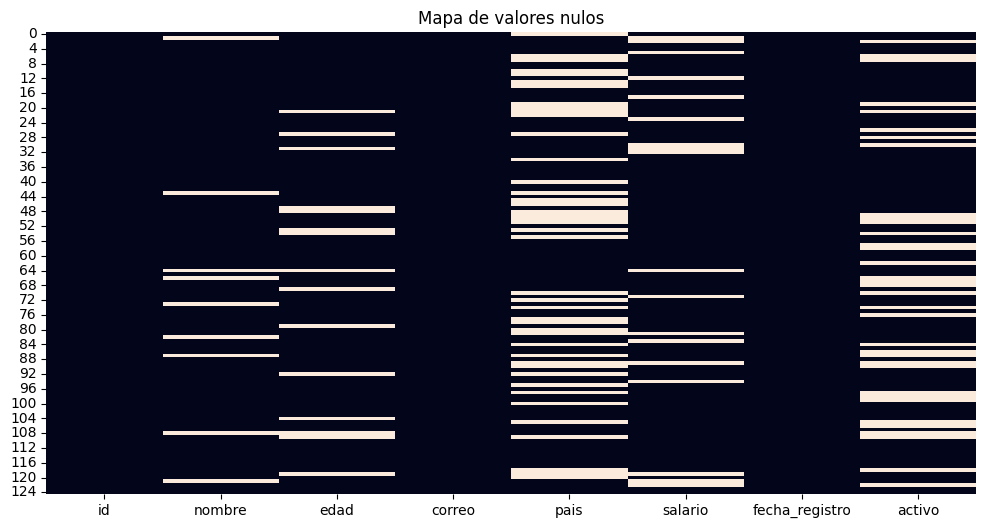

In [15]:
plt.figure(figsize = (12, 6))
sns.heatmap(dfSucio.isnull(), cbar = False)
plt.title("Mapa de valores nulos")
plt.show

In [16]:
dfSucio.duplicated().sum()

np.int64(5)

In [17]:
dfSucio.drop_duplicates(inplace=True)

In [38]:
#Corregir edades invalidas
dfSucio[(dfSucio["edad"] < 0) | (dfSucio["edad"] > 100)]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo


In [40]:
dfSucio.loc[(dfSucio["edad"] < 0) | (dfSucio["edad"] > 110), "edad"] = np.nan

In [41]:
#Calculamos la mediana de la edad
mediana_edad = dfSucio["edad"].median()

In [22]:
mediana_edad

np.float64(30.0)

In [42]:
dfSucio["edad"] = dfSucio["edad"].fillna (mediana_edad)

In [31]:
dfSucio["edad"].describe()

count    120.000000
mean      30.325000
std        4.745918
min       22.000000
25%       30.000000
50%       30.000000
75%       31.250000
max       40.000000
Name: edad, dtype: float64

In [32]:
#Corregimos anomalia de salarios negativos
dfSucio[dfSucio["salario"] < 0]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo


In [33]:
dfSucio.loc[(dfSucio["salario"] < 0), "salario"] = np.nan

In [34]:
mediana_salario = dfSucio["salario"].median()

In [35]:
mediana_salario

np.float64(15000.0)

In [36]:
dfSucio["salario"] = dfSucio["salario"] .fillna(mediana_salario)

In [37]:
dfSucio["salario"].describe()

count      120.000000
mean     16741.666667
std       4401.099621
min      12000.000000
25%      15000.000000
50%      15000.000000
75%      18000.000000
max      25000.000000
Name: salario, dtype: float64

In [66]:
#Corregir correos no validos
dfSucio[~dfSucio["correo"] .str.contains("@", na = False)]

,id,nombre,edad,correo,pais,salario,fecha_registro,activo
3,4,Joyce Williams,30.0,NaN,Argentina,25000.0,2025-02-23,0
4,5,Elaine Sanchez,30.0,NaN,México,25000.0,2025-03-28,1
18,19,Nicholas Curry,35.0,NaN,México,12000.0,2025-11-22,1
21,22,Carrie Griffith,30.0,NaN,Argentina,15000.0,2025-05-05,1
30,31,Mrs. Sara Johnson,35.0,NaN,Argentina,15000.0,2026-03-07,1
40,41,Cynthia Arnold,30.0,NaN,Argentina,25000.0,2024-11-03,0
65,66,Michael Lopez,40.0,NaN,España,15000.0,2025-12-01,0
78,79,Charles Page,25.0,NaN,Argentina,15000.0,2025-09-01,0
87,88,NaN,22.0,NaN,Argentina,12000.0,2025-03-07,1
88,89,Erika Bernard,30.0,NaN,Argentina,12000.0,2024-11-16,1


In [47]:
#Correos no validos
correo_invalido = ~dfSucio["correo"] .str.contains("@", na = False)
dfSucio.loc [correo_invalido, "correo"] = pd.NA

In [53]:
#Corregir países no asignados
dfSucio["pais"].isnull().sum()

np.int64(0)

In [50]:
moda_pais = dfSucio["pais"].mode()[0]

In [51]:
moda_pais

'Argentina'

In [52]:
dfSucio["pais"] = dfSucio["pais"].fillna(moda_pais)

In [57]:
dfSucio.dtypes

id                         int64
nombre                       str
edad                     float64
correo                       str
pais                         str
salario                  float64
fecha_registro    datetime64[us]
activo                       str
dtype: object

In [56]:
#Convertimos la fecha
dfSucio["fecha_registro"] = pd.to_datetime(dfSucio["fecha_registro"])

In [58]:
dfSucio["fecha_registro"] .dt.year

0      2026
1      2026
2      2026
3      2025
4      2025
       ... 
115    2024
116    2024
117    2026
118    2025
119    2026
Name: fecha_registro, Length: 120, dtype: int32

In [61]:
#Categorizar el campo activo
dfSucio["activo"] .value_counts(dropna = False)

activo
Sí    81
No    39
Name: count, dtype: int64

In [60]:
dfSucio ["activo"] = dfSucio ["activo"].fillna ("Sí")

In [62]:
#Convertimos a binario
dfSucio ["activo"] = dfSucio ["activo"] .map({
    "Sí": 1,
    "No": 0
})

In [63]:
dfSucio["activo"] .value_counts(dropna = False)

activo
1    81
0    39
Name: count, dtype: int64

In [64]:
(dfSucio.isnull().sum()/len (dfSucio)) * 100

id                 0.000000
nombre             6.666667
edad               0.000000
correo            10.000000
pais               0.000000
salario            0.000000
fecha_registro     0.000000
activo             0.000000
dtype: float64

In [ ]:
# Conclusiones
Durante la práctica se identificaron y corrigieron los siguientes problemas:
1. Borrar los datos duplicados
2. Corregir datos invalidos y atipicos
3. Realizar y corregir tipos de datos
4. Categorizar campos que sean necesarios